# Inspect CSV and GeoJSON files

This notebook:

- loads `dati_schede.csv` and `lat_long.json`;
- prints file characteristics and record counts;
- inspects columns, data types, missing values, and geometry;
- checks duplicates and missing IDs;
- compares CSV `id_scheda_originale` with GeoJSON `properties.ID`;
- lists IDs found in only one of the two files;
- validates one-to-one matching.

In [ ]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = Path("../data/dati_schede.csv")
GEOJSON_PATH = Path("../data/lat_long.json")

CSV_ID_COLUMN = "id_scheda_originale"
GEOJSON_ID_PROPERTY = "ID"

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)

print("CSV:", CSV_PATH)
print("GeoJSON:", GEOJSON_PATH)


CSV: /mnt/data/dati_schede.csv
GeoJSON: /mnt/data/lat_long.json


In [ ]:
# Load the two files
csv_df = pd.read_csv(CSV_PATH, low_memory=False)

with GEOJSON_PATH.open("r", encoding="utf-8") as file:
    geojson = json.load(file)

features = geojson.get("features", [])

geo_rows = []
for index, feature in enumerate(features):
    geometry = feature.get("geometry") or {}
    properties = feature.get("properties") or {}
    coordinates = geometry.get("coordinates")

    geo_rows.append({
        "_feature_index": index,
        "_geometry_type": geometry.get("type"),
        "_coordinates": coordinates,
        **properties,
    })

geo_df = pd.DataFrame(geo_rows)

print(f"CSV loaded: {len(csv_df):,} rows × {csv_df.shape[1]:,} columns")
print(f"GeoJSON loaded: {len(features):,} features")


CSV loaded: 44,363 rows × 243 columns
GeoJSON loaded: 44,363 features


## 1. Basic file characteristics

In [ ]:
def file_characteristics(path):
    stat = path.stat()
    return {
        "file": path.name,
        "size_bytes": stat.st_size,
        "size_mb": stat.st_size / 1024**2,
        "suffix": path.suffix,
    }

file_summary = pd.DataFrame([
    file_characteristics(CSV_PATH),
    file_characteristics(GEOJSON_PATH),
])

display(file_summary)

print("\nGeoJSON top-level type:", geojson.get("type"))
print("GeoJSON top-level keys:", list(geojson.keys()))
print("CSV shape:", csv_df.shape)
print("GeoJSON table shape:", geo_df.shape)


,file,size_bytes,size_mb,suffix
0,dati_schede.csv,149414155,142.492442,.csv
1,lat_long.json,9698906,9.249598,.json



GeoJSON top-level type: FeatureCollection
GeoJSON top-level keys: ['type', 'features']
CSV shape: (44363, 243)
GeoJSON table shape: (44363, 9)


## 2. CSV inspection

In [ ]:
print("CSV columns:")
display(pd.DataFrame({
    "column": csv_df.columns,
    "dtype": csv_df.dtypes.astype(str).values,
    "non_null": csv_df.notna().sum().values,
    "missing": csv_df.isna().sum().values,
    "missing_percent": (csv_df.isna().mean().values * 100).round(2),
}).head(50))

print(f"\nTotal CSV columns: {csv_df.shape[1]:,}")
display(csv_df.head())


CSV columns:


,column,dtype,non_null,missing,missing_percent
0,id_scheda_originale,object,44363,0,0.00
1,cdidentificazione__tsktipo_scheda,object,43263,1100,2.48
2,cdidentificazione__lirlivello_catalogazione,object,43263,1100,2.48
3,nctcodice_univoco_iccd__nctrcodice_regione,float64,43263,1100,2.48
4,nctcodice_univoco_iccd__nctnnumero_catalogo_generale,float64,43263,1100,2.48
5,nctcodice_univoco_iccd__escente_schedatore,object,43263,1100,2.48
6,nctcodice_univoco_iccd__ecpente_competente_per_tutela,object,43263,1100,2.48
7,ogdefinizione_denominazione__ambambito_di_tutela_mic,object,43263,1100,2.48
8,ogdefinizione_denominazione__ctgcategoria,object,43263,1100,2.48
9,ogdefinizione_denominazione__ogtdefinizione_tipologica,object,43263,1100,2.48



Total CSV columns: 243


,id_scheda_originale,cdidentificazione__tsktipo_scheda,cdidentificazione__lirlivello_catalogazione,nctcodice_univoco_iccd__nctrcodice_regione,nctcodice_univoco_iccd__nctnnumero_catalogo_generale,nctcodice_univoco_iccd__escente_schedatore,nctcodice_univoco_iccd__ecpente_competente_per_tutela,ogdefinizione_denominazione__ambambito_di_tutela_mic,ogdefinizione_denominazione__ctgcategoria,ogdefinizione_denominazione__ogtdefinizione_tipologica,ogdefinizione_denominazione__ogunumero_spazi,lclocalizzazione__lcrregione,lclocalizzazione__lcpprovincia,lclocalizzazione__lcccomune,acbaccessibilità_del_bene__acbaaccessibilità,acbaccessibilità_del_bene__acblspecifiche,ctsidentificativi_catastali__ctsccomune_catastale,ctsidentificativi_catastali__ctsttipo_catasto,ctsidentificativi_catastali__ctsffoglio,gegeoreferenziazione__geltipo_di_localizzazione,gegeoreferenziazione__gettipo_di_georeferenziazione,gegeoreferenziazione__gepsistema_di_riferimento,gpbbase_cartografica__gpbbdescrizione_sintetica,cacontesto_ambientale_naturale_paesaggistico__cabcontesto_paesaggistico_(sintesi),cacontesto_ambientale_naturale_paesaggistico__caaquadro_attuale,...,rserelazioni_con_altri_beni_catalogati__rezspecifiche_sulle_relazioni,aszrecinzioni__asznnote,accaltro_codice__accpprogetto,prepreesistenze__prepposizione,prepreesistenze__precriferimento_cronologico,ctsidentificativi_catastali__cteelementi_confinanti,pvlaltro_toponimo__pvlsnote,asppavimentazioni__aspqquantità,accaltro_codice__accrriferimento_cronologico,accaltro_codice__accsnote,iqainquinamento_ambientale__iqattipo,iqainquinamento_ambientale__iqaddescrizione_della_situazione,ctsidentificativi_catastali__ctspproprietari,tucondizione_giuridica__nvcprovvedimenti_amministrativi-specifiche,asrspazio__asrldefinizione_tipologica_locale,tucondizione_giuridica__cdscondizione_giuridica_specifiche,accaltro_codice__accwindirizzo_web,prepreesistenze__preedenominazione,prepreesistenze__nscnotizie_storico_critiche,prepreesistenze__naiconsiderazioni_sugli_aspetti_di_interesse,prepreesistenze__prennote,csdati_catastali__cteelementi_confinanti,gpbbase_cartografica__gpbuindirizzo_web_(url),csdati_catastali__ctnnote,gegeoreferenziazione__gennote
0,ce9c9265-54dd-4779-9c4b-cc282dc908e3,AR,P,6.0,182407.0,ICCD,S239,architettonico e paesaggistico,EDIFICIO SINGOLO,casa con loggiato,nr,Friuli-Venezia Giulia,UD,Dignano,no,non è stato possibile accedere alla proprietà,D300,Catasto misto,17,localizzazione fisica,georeferenziazione areale,WGS84,OSM,pianura,"Dal punto di vista geomorfologico, il territorio su cui insiste l’edificio, ricade nell’alta pianura friulana e ison...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6e02ff7c-2b9d-40d0-a14c-e8f4d03d9a83,AR,I,20.0,252733.0,ICCD,S252,architettonico e paesaggistico,EDIFICIO SINGOLO,casa a corte chiusa,nr,Sardegna,SU,Soleminis,no,non è stato possibile accedere alla proprietà,I797,Catasto misto,17,localizzazione fisica,georeferenziazione areale,WGS84,OSM,collina,"Edificio abitativo a corte interna con annesso, posto all'interno dell'area individuata dal PPR come ""Centro di anti...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,814d64dd-d0f5-4c01-ace8-968ec355547e,AR,I,17.0,223849.0,ICCD,S284,architettonico e paesaggistico,EDIFICIO CON ANNESSI,casa a scala esterna,1,Basilicata,PZ,San Martino d'Agri,no,non è stato possibile accedere alla proprietà,San Martino D'Agri,Catasto Fabbricati,27,localizzazione fisica,georeferenziazione areale,WGS84,OSM,altopiano,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,7aea73d3-286c-4fa1-aade-0883bd9f9c78,AR,P,6.0,182399.0,ICCD,S239,architettonico e paesaggistico,EDIFICIO CON ANNESSI,cascina,2,Friuli-Venezia Giulia,UD,Comune di Pavia di Udine,in parte,accesso alla proprietà e non agli edifici,G389,Catasto misto,28,localizzazione fisica,georeferenziazione areale,WGS84,OSM,pian

,missing_percent
csdati_catastali__ctnnote,99.995492
gegeoreferenziazione__gennote,99.993238
ctsidentificativi_catastali__ctsssubalterno,99.988729
prepreesistenze__prennote,99.984221
prepreesistenze__naiconsiderazioni_sugli_aspetti_di_interesse,99.984221
gpbbase_cartografica__gpbuindirizzo_web_(url),99.981967
csdati_catastali__cteelementi_confinanti,99.979713
prepreesistenze__nscnotizie_storico_critiche,99.979713
prepreesistenze__prepposizione,99.975205
tucondizione_giuridica__cdscondizione_giuridica_specifiche,99.966188


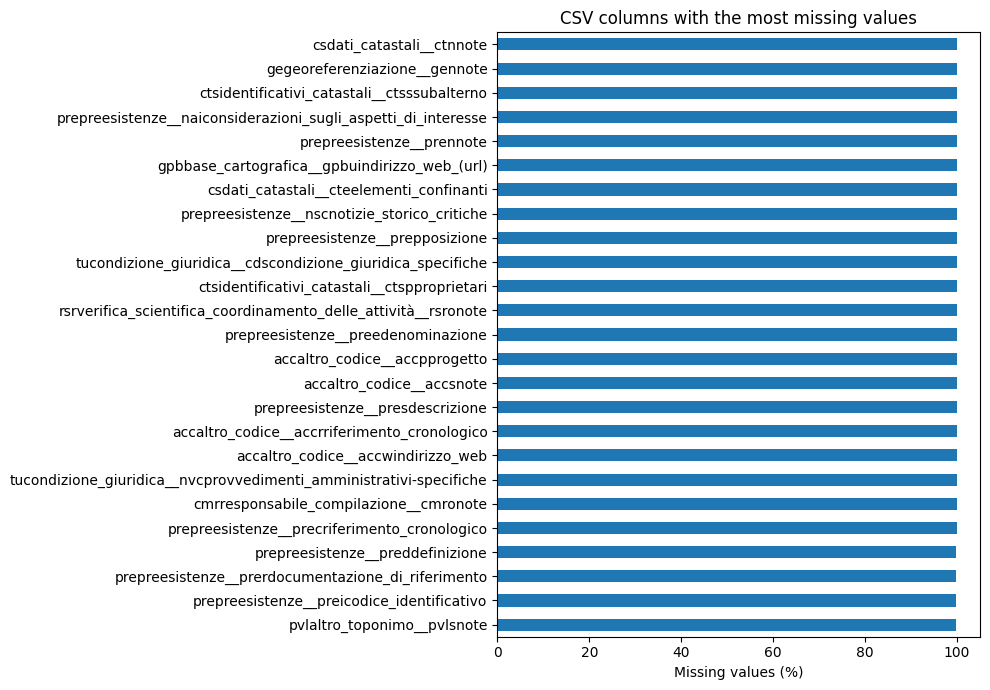

In [5]:
# Highest missing-value percentages in the CSV
csv_missing = (
    csv_df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_percent")
    .to_frame()
)

display(csv_missing.head(25))

csv_missing.head(25).sort_values("missing_percent").plot(
    kind="barh",
    figsize=(10, 7),
    legend=False,
    title="CSV columns with the most missing values",
)
plt.xlabel("Missing values (%)")
plt.tight_layout()
plt.show()


## 3. GeoJSON inspection

In [6]:
print("Geometry type counts:")
display(geo_df["_geometry_type"].value_counts(dropna=False).rename("count").to_frame())

print("\nGeoJSON property columns:")
geo_property_columns = [
    column for column in geo_df.columns
    if not column.startswith("_")
]
display(pd.DataFrame({
    "column": geo_property_columns,
    "dtype": geo_df[geo_property_columns].dtypes.astype(str).values,
    "non_null": geo_df[geo_property_columns].notna().sum().values,
    "missing": geo_df[geo_property_columns].isna().sum().values,
}))

display(geo_df.head())


Geometry type counts:


,count
_geometry_type,
Point,44363



GeoJSON property columns:


,column,dtype,non_null,missing
0,ID,object,44363,0
1,LG,object,44363,0
2,REGIONE,int64,44363,0
3,TIPO,int64,44363,0
4,STATO_ATTU,int64,44363,0
5,L3field_2,object,44363,0


,_feature_index,_geometry_type,_coordinates,ID,LG,REGIONE,TIPO,STATO_ATTU,L3field_2
0,0,Point,"[804532.6077167223, 5110808.356105851]",ce9c9265-54dd-4779-9c4b-cc282dc908e3,,5,1,5,
1,1,Point,"[515719.62663000147, 4355316.811596198]",6e02ff7c-2b9d-40d0-a14c-e8f4d03d9a83,,19,1,5,
2,2,Point,"[1098726.0028771968, 4476786.505051931]",814d64dd-d0f5-4c01-ace8-968ec355547e,,16,1,5,
3,3,Point,"[831898.954715131, 5100476.362457695]",7aea73d3-286c-4fa1-aade-0883bd9f9c78,,5,1,5,
4,4,Point,"[888203.0546069357, 4716066.684009123]",d8d256d7-e480-40c6-bd8a-0d8d4dd66f45,,12,1,5,


In [7]:
# Coordinate validation and range
def valid_point_coordinates(value):
    return (
        isinstance(value, (list, tuple))
        and len(value) >= 2
        and all(isinstance(v, (int, float, np.number)) for v in value[:2])
        and all(np.isfinite(v) for v in value[:2])
    )

valid_coordinate_mask = geo_df["_coordinates"].map(valid_point_coordinates)

print("Features with valid numeric point coordinates:",
      f"{valid_coordinate_mask.sum():,} / {len(geo_df):,}")

if valid_coordinate_mask.any():
    coordinates = np.array(
        geo_df.loc[valid_coordinate_mask, "_coordinates"].map(lambda value: value[:2]).tolist()
    )

    coordinate_summary = pd.DataFrame({
        "axis": ["x", "y"],
        "minimum": coordinates.min(axis=0),
        "maximum": coordinates.max(axis=0),
        "mean": coordinates.mean(axis=0),
    })

    display(coordinate_summary)


Features with valid numeric point coordinates: 44,363 / 44,363


,axis,minimum,maximum,mean
0,x,3.182917e+05,1.307975e+06,7.567223e+05
1,y,4.070360e+06,5.215426e+06,4.779412e+06


## 4. ID quality checks

In [8]:
assert CSV_ID_COLUMN in csv_df.columns, (
    f"CSV ID column not found: {CSV_ID_COLUMN!r}"
)
assert GEOJSON_ID_PROPERTY in geo_df.columns, (
    f"GeoJSON ID property not found: {GEOJSON_ID_PROPERTY!r}"
)

def normalize_id(series):
    return (
        series.astype("string")
        .str.strip()
        .replace("", pd.NA)
    )

csv_ids = normalize_id(csv_df[CSV_ID_COLUMN])
geo_ids = normalize_id(geo_df[GEOJSON_ID_PROPERTY])

id_quality = pd.DataFrame({
    "dataset": ["CSV", "GeoJSON"],
    "records": [len(csv_ids), len(geo_ids)],
    "missing_ids": [csv_ids.isna().sum(), geo_ids.isna().sum()],
    "non_missing_ids": [csv_ids.notna().sum(), geo_ids.notna().sum()],
    "unique_ids": [csv_ids.nunique(dropna=True), geo_ids.nunique(dropna=True)],
    "duplicate_rows": [
        csv_ids.duplicated(keep=False).sum(),
        geo_ids.duplicated(keep=False).sum(),
    ],
})

display(id_quality)


,dataset,records,missing_ids,non_missing_ids,unique_ids,duplicate_rows
0,CSV,44363,0,44363,44363,0
1,GeoJSON,44363,0,44363,44363,0


In [9]:
csv_duplicate_ids = (
    csv_ids.dropna()
    .value_counts()
    .loc[lambda counts: counts > 1]
    .rename("csv_count")
)

geo_duplicate_ids = (
    geo_ids.dropna()
    .value_counts()
    .loc[lambda counts: counts > 1]
    .rename("geojson_count")
)

print(f"Duplicated CSV IDs: {len(csv_duplicate_ids):,}")
display(csv_duplicate_ids.head(20).to_frame())

print(f"Duplicated GeoJSON IDs: {len(geo_duplicate_ids):,}")
display(geo_duplicate_ids.head(20).to_frame())


Duplicated CSV IDs: 0


,csv_count
id_scheda_originale,


Duplicated GeoJSON IDs: 0


,geojson_count
ID,


## 5. Compare IDs between the two files

In [10]:
csv_id_set = set(csv_ids.dropna())
geo_id_set = set(geo_ids.dropna())

only_in_csv = sorted(csv_id_set - geo_id_set)
only_in_geojson = sorted(geo_id_set - csv_id_set)
matching_ids = csv_id_set & geo_id_set
all_ids = csv_id_set | geo_id_set

comparison = pd.DataFrame({
    "metric": [
        "Unique IDs in CSV",
        "Unique IDs in GeoJSON",
        "Matching unique IDs",
        "Only in CSV",
        "Only in GeoJSON",
        "Union of unique IDs",
        "Exact set match",
    ],
    "value": [
        len(csv_id_set),
        len(geo_id_set),
        len(matching_ids),
        len(only_in_csv),
        len(only_in_geojson),
        len(all_ids),
        csv_id_set == geo_id_set,
    ],
})

display(comparison)

if csv_id_set == geo_id_set:
    print("✅ The two files contain exactly the same set of non-null IDs.")
else:
    print("❌ The ID sets do not match exactly.")


,metric,value
0,Unique IDs in CSV,44363
1,Unique IDs in GeoJSON,44363
2,Matching unique IDs,44363
3,Only in CSV,0
4,Only in GeoJSON,0
5,Union of unique IDs,44363
6,Exact set match,True


✅ The two files contain exactly the same set of non-null IDs.


In [11]:
print("Sample IDs only in CSV:")
display(pd.DataFrame({"id_only_in_csv": only_in_csv[:50]}))

print("Sample IDs only in GeoJSON:")
display(pd.DataFrame({"id_only_in_geojson": only_in_geojson[:50]}))


Sample IDs only in CSV:


,id_only_in_csv


Sample IDs only in GeoJSON:


,id_only_in_geojson


## 6. Row-level matching validation

In [12]:
csv_id_table = pd.DataFrame({
    "id": csv_ids,
    "csv_row": csv_df.index,
})

geo_id_table = pd.DataFrame({
    "id": geo_ids,
    "geojson_feature": geo_df["_feature_index"],
})

id_match_table = csv_id_table.merge(
    geo_id_table,
    on="id",
    how="outer",
    indicator=True,
)

display(id_match_table["_merge"].value_counts(dropna=False).rename("rows").to_frame())

print("\nRows not matched on both sides:")
display(
    id_match_table.loc[id_match_table["_merge"] != "both"]
    .head(100)
)


,rows
_merge,
both,44363
left_only,0
right_only,0



Rows not matched on both sides:


,id,csv_row,geojson_feature,_merge


## 7. Final validation summary

In [13]:
checks = {
    "same_number_of_records": len(csv_df) == len(geo_df),
    "csv_has_no_missing_ids": csv_ids.isna().sum() == 0,
    "geojson_has_no_missing_ids": geo_ids.isna().sum() == 0,
    "csv_ids_are_unique": csv_ids.dropna().is_unique,
    "geojson_ids_are_unique": geo_ids.dropna().is_unique,
    "id_sets_match_exactly": csv_id_set == geo_id_set,
}

final_summary = pd.DataFrame({
    "check": checks.keys(),
    "passed": checks.values(),
})

display(final_summary)

if final_summary["passed"].all():
    print("✅ All checks passed: the files have one-to-one matching IDs.")
else:
    print("⚠️ One or more checks failed. Review the sections above.")


,check,passed
0,same_number_of_records,True
1,csv_has_no_missing_ids,True
2,geojson_has_no_missing_ids,True
3,csv_ids_are_unique,True
4,geojson_ids_are_unique,True
5,id_sets_match_exactly,True


✅ All checks passed: the files have one-to-one matching IDs.
